In [163]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
import importlib
import main_functions
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

importlib.reload(main_functions) 
from main_functions import *

In [165]:
def detection_of_bullish_belt_hold(data, body_rate=0.5):
    """
    Обнаружение бычьего паттерна "Захват за пояс" (Bullish Belt Hold) и генерация торгового сигнала.
    
    Паттерн "Бычий захват за пояс" - это односвечная модель разворота, которая формируется
    на нисходящем тренде и сигнализирует о потенциальном развороте вверх.
    
    Характеристики паттерна:
        - Цена открытия (open) равна минимуму свечи (low) — нет нижней тени
        - Тело свечи большое (занимает >50% от всего диапазона свечи)
        - Цена закрытия (close) находится в верхней части свечи
        - Верхняя тень может присутствовать, но обычно небольшая
    
    Логика работы функции:
        1. Проверяется условие: open == low (нет нижней тени)
        2. Тело свечи > 0 (открытие и закрытие не равны)
        3. Соотношение тела ко всему диапазону свечи > body_rate (по умолчанию >50%)
        4. Если условия выполнены — свеча помечается как паттерн 'Bullish Belt Hold'
        5. Торговый сигнал (signal = 1) генерируется НА СЛЕДУЮЩЕЙ свече
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        body_rate (float, default=0.5): Минимальное допустимое соотношение тела свечи
                                        ко всему диапазону свечи (body / full_candle).
                                        По умолчанию 0.5 (тело ≥ 50% от всей свечи).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с добавленными столбцами:
            - pattern (int): 1 — на текущей свече обнаружен паттерн "Bullish Belt Hold";
                             0 — паттерн отсутствует.
            - signal (int): 1 — торговый сигнал на покупку на следующей свече;
                            0 — сигнала нет.
            - body_rate (float): Скопированное значение параметра body_rate.
            - strategy (str): Название стратегии — всегда 'bullish_belt_hold'.
    """
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['body_rate'] = body_rate
    data['strategy'] = 'bullish_belt_hold'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = data['close'] - data['open']
    
    
    # Базовое условие для формации молот
    mask = ((data['low'] == data['open']) & (body > 0) & (np.abs(body) / full_candle > body_rate))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data


In [166]:
tatneft = pd.read_csv(r'C:\Users\user\Desktop\Проект 1 года обучения\Проверка эффективности паттернов\Данные для анализа\PLZL.txt')
with open(r'C:\Users\user\Desktop\Проект 1 года обучения\Повышение эффективности с помощью ML\Результаты паттернов\results_strategies_1candle.pkl', 'rb') as file:
    tatneft_result = pickle.load(file)
display(tatneft_result.head(3))
display(tatneft.head(2))

,ticker,strategy name,period,N,body_rate,lower_shadow_rate,up_shadow_rate,count of trades,profit factor,total percent return,...,capital curve net,capital curve without commission,profit percent net,percent profit without commission,profit factor rank,R2 rank,profit/loss ratio rank,max drawdown rank,best model,buy and hold (%)
0,PLZL,bullish_belt_hold,1h,25,0.5,0,0,625,1.558,1530.73,...,time 2009-01-11 18:00:00 1.094990e+05 2009-...,time 2009-01-11 18:00:00 1.096780e+05 2009-...,time 2009-01-11 18:00:00 0.09499 2009-01-26...,time 2009-01-11 18:00:00 0.09678 2009-01-26...,3.0,3.0,1.0,2.0,9.0,2645.5
1,PLZL,maribozy,D,2,0.0,0,0,755,1.384,550.73,...,time 2009-01-13 100285.000000 2009-02-18 ...,time 2009-01-13 1.004550e+05 2009-02-18 ...,time 2009-01-13 0.00285 2009-02-18 -0.009...,time 2009-01-13 0.00455 2009-02-18 -0.007...,2.0,1.0,2.0,3.0,8.0,2645.5
2,PLZL,bullish_belt_hold,1h,15,0.8,0,0,657,1.295,233.86,...,time 2009-01-11 18:00:00 107467.000000 2009...,time 2009-01-11 18:00:00 1.076430e+05 2009-...,time 2009-01-11 18:00:00 0.07467 2009-02-19...,time 2009-01-11 18:00:00 0.07643 2009-02-19...,1.0,2.0,3.0,1.0,7.0,2645.5


,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,PLZL,1,20090111,103000,80.001,80.30,78.103,79.490,51300
1,PLZL,1,20090111,103100,79.490,79.49,78.500,78.609,8940


In [167]:
tatneft_graph = good_dataframe(tatneft, timeframe='1h')

In [168]:
def detection_of_hammer(data, lower_shadow_rate=1.5, body_rate=0.4, up_shadow_rate=0.05):

    """
    Обнаружение бычьего паттерна "Молот" (Hammer).
    
    Паттерн "Молот" - это односвечная модель разворота, которая формируется на нисходящем тренде
    и сигнализирует о потенциальном развороте вверх. Характеризуется маленьким телом в верхней
    части свечи и длинной нижней тенью.
    
    Параметры паттерна:
        - Тело свечи занимает небольшую часть от всего диапазона (по умолчанию ≤30%)
        - Нижняя тень значительно длиннее тела (по умолчанию ≥2 * тела)
        - Верхняя тень минимальна или отсутствует (по умолчанию ≤ 0.1 * тела)
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            - open (float): Цена открытия
            - high (float): Максимальная цена
            - low (float): Минимальная цена
            - close (float): Цена закрытия
        lower_shadow_rate (float): Минимальное соотношение нижней тени к телу.
                                   По умолчанию 2 (нижняя тень > 2 * тела).
        body_rate (float): Максимальное соотношение тела ко всей свече.
                           По умолчанию 0.3 (тело < 30% свечи).
        up_shadow_rate (float): Максимальное соотношение верхней тени к телу.
                                По умолчанию 1 (верхняя тень < 0.1 * тела).
    
    Returns:
        pd.DataFrame: Исходный DataFrame с дополнительными столбцами:
            - pattern (int): 1 - обнаружен паттерн "Молот" на текущей свече,
                             0 - паттерн отсутствует
            - strategy (str): Название стратегии - 'hummer'
    
"""
    data = data.copy()
    data['pattern'] = 0
    data['signal'] = 0
    data['lower_shadow_rate'] = lower_shadow_rate
    data['up_shadow_rate'] = up_shadow_rate
    data['body_rate'] = body_rate
    data['strategy'] = 'hammer'
    # Векторизованные вычисления
    full_candle = data['high'] - data['low']
    body = np.abs(data['close'] - data['open'])
    lower_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    

    # Базовое условие для формации молот
    mask = ((body / full_candle < body_rate) & 
                      (lower_shadow / body > lower_shadow_rate) &
                      (up_shadow / body < up_shadow_rate))

    
    data.loc[mask, 'pattern'] = 1
    data.loc[mask.shift(1).fillna(False), 'signal'] = 1
        
    
    return data

In [169]:
def preperation_to_modeling_1candle(data, period, func, N, profit):
    """Функция предназначена для подготовки датафрейма к дальнейшему моделированию

    Args:
        data (pd.DataFrame): 1-минутный таймфрейм
        period (object): Передаем период из стратегии
        func (function): Какой паттерн проверяем?
        N (int): Сколько следующих свеч удерживаем паттерн?
        profit (pd.Series): Численные результаты торгов

    Returns:
        Подготовленный датафрейм для использования ml
    """
    data_timeframe = good_dataframe(data, period)
    data_with_pattern = func(data_timeframe, 0.5)
    
    # Обрезка
    data_with_pattern.loc[len(data_with_pattern) - 51 : len(data_with_pattern), ['pattern', 'signal']] = 0
    data_filter = filter_min_distance(data_with_pattern, 'signal', N)
    data_filter['signal'] = data_filter['signal'].shift(-1)
    
    
    data_filter.drop(['pattern', 'body_rate', 'per', 'ticker', 'strategy'], axis=1, inplace=True)
    data_filter.dropna(inplace=True)
    
    # Соединяем доходности
    result = profit.loc[0, 'profit percent net']
    data_filter = data_filter.set_index('time')
    final_data = data_filter.join(result).fillna(0)
    final_data = final_data.reset_index()
    final_data['profit_percent_net'] = final_data['profit_percent_net'].shift(-1)
    final_data.dropna(inplace=True)
    return final_data

df = preperation_to_modeling_1candle(tatneft, '1h', detection_of_bullish_belt_hold, 25, tatneft_result)

In [170]:
df

,time,open,high,low,close,volume,signal,profit_percent_net
0,2009-01-11 10:00:00,80.001,80.300,76.000,78.800,749570,0.0,0.0
1,2009-01-11 11:00:00,78.745,78.949,76.800,77.888,643210,0.0,0.0
2,2009-01-11 12:00:00,77.841,78.200,77.401,77.580,293980,0.0,0.0
3,2009-01-11 13:00:00,77.507,77.765,77.414,77.699,150350,0.0,0.0
4,2009-01-11 14:00:00,77.655,77.710,77.500,77.670,66140,0.0,0.0
...,...,...,...,...,...,...,...,...
47269,2026-03-31 17:00:00,2085.000,2097.800,2083.000,2089.400,133545,0.0,0.0
47270,2026-03-31 18:00:00,2089.200,2104.400,2087.000,2100.800,69610,0.0,0.0
47271,2026-03-31 19:00:00,2101.000,2116.200,2100.000,2106.400,82783,0.0,0.0
47272,2026-03-31 20:00:00,2106.400,2113.400,2102.400,2105.000,42990,0.0,0.0


In [171]:
# Признаки по дате и времени
def data_time_features(data):
    """Функция для создания временных признаков

    Args:
        data (pd.DataFrame): Датафрейм с разметкой данных

    Returns:
       data (pd.DataFrame): Новый датафрейм с временными признаками
    """
    data = data.copy()
    data['time'] = pd.to_datetime(data['time'])
    data['months'] = data['time'].dt.month
    data['days'] = data['time'].dt.day
    data['hours'] = data['time'].dt.hour
    data['day_of_week'] = data['time'].dt.day_of_week
    return data

In [172]:
# Признаки по каждой свече
def data_one_candle_features_1(data):
    """
    Расчет характеристик свечей для ML-моделей.
    
    Признаки для текущей свечи (N):
        - has_body: наличие тела свечи
        - ratio_body_to_all_candle: отношение тела к полному диапазону (High-Low)
        - ratio_up_shadow_to_body: отношение верхней тени к телу
        - ratio_low_shadow_to_body: отношение нижней тени к телу
        - ratio_up_to_low_shadow: соотношение верхней и нижней теней
        - has_both_shadows: наличие обеих теней
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные признаки (NaN заменены на 0)"""
    data = data.copy()
    # Отношение тела свечи ко всей свече
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    
    # есть ли тело и есть ли свеча
    data['has_body'] = (body > 0).astype('int')
    data['has_full_candle'] = (full_candle > 0).astype('int')
    
    data['ratio_body_to_all_candle'] = np.where(full_candle > 0, body / full_candle, np.nan)
    
    # Отношение верхней тени к телу свечи
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    data['ratio_up_shadow_to_body'] = np.where(body > 0, up_shadow / body, np.nan)


    # Отношение нижней тени к телу свечи
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
    
    data['ratio_low_shadow_to_body'] = np.where(body > 0, low_shadow / body, np.nan)

    # Отношение верхней тени к нижней тени
    data['ratio_up_to_low_shadow'] = np.where((low_shadow > 0) & (up_shadow > 0), up_shadow / low_shadow, np.nan)

    # Добавляем бинарный признак: есть ли обе тени
    data['has_both_shadows'] = ((low_shadow > 0) & (up_shadow > 0)).astype('int')

    data = data.fillna(0)

    
    return data

In [173]:
def data_one_candle_features_2(data):
    """Расчет ATR-нормированных признаков свечей.
    
    Признаки (нормированы на ATR):
        - body_ATR: размер тела свечи
        - full_candle_ATR: полный диапазон High-Low
        - up_shadow_ATR: верхняя тень
        - low_shadow_ATR: нижняя тень
    
    Args:
        data (pd.DataFrame): DataFrame с колонками open, high, low, close
    
    Returns:
        pd.DataFrame: Отфильтрованный DataFrame (удалены строки без ATR) с добавленными признаками"""
    
    data = data.copy()
    def ATR(data, period=14):
        high = data['high']
        low = data['low']
        close = data['close']
        
        # True Range компоненты
        high_low = high - low                                    # текущий бар
        high_close_prev = np.abs(high - close.shift(1))         # high сегодня - close вчера
        low_close_prev = np.abs(low - close.shift(1))           # low сегодня - close вчера
        
        # True Range (максимум из трёх)
        TR = np.maximum(high_low, np.maximum(high_close_prev, low_close_prev))
        
        # ATR (простое скользящее среднее)
        ATR = TR.rolling(period).mean()
        return ATR
    
    atr = ATR(data).shift(1)
    data = data[~atr.isna()].copy()
    atr = atr[~atr.isna()]
    
    body = np.abs(data['close'] - data['open'])
    full_candle = np.abs(data['high'] - data['low'])
    up_shadow = np.where(data['close'] - data['open'] > 0, data['high'] - data['close'], data['high'] - data['open'])
    low_shadow = np.where(data['close'] - data['open'] > 0, data['open'] - data['low'], data['close'] - data['low'])
 
    
    atr_safe = np.maximum(atr, 1e-8)
    
    # Тело свечи / ATR
    data['body_ATR'] = body / atr_safe
    
    # Вся свеча / ATR
    data['full_candle_ATR'] = full_candle / atr_safe

    # Верхняя тень / ATR
    data['up_shadow_ATR'] = up_shadow / atr_safe
    
    # Нижняя тень / ATR
    data['low_shadow_ATR'] = low_shadow / atr_safe
    
    return data

In [174]:
def indicators(data):
    """
    Расчет технических индикаторов для ML-моделей.
    
    Индикаторы для свечей N:
        - RSI (14): индекс относительной силы
        - SMA (5,10,20,30,50,100,150,200): процентное отклонение цены от скользящей средней
        - Volume Z-score: нормированный объем (63-период)
        - Стохастик (14,3): %K и %D линии
    
    Args:
        data (pd.DataFrame): DataFrame с колонками close, open, high, low
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные индикаторы
    """
    data = data.copy()
    
    # RSI
    def rsi(prices, n=14):
        deltas = np.diff(prices)
        gains = np.where(deltas > 0, deltas, 0)
        loss = np.where(deltas < 0, -deltas, 0)
        
        avg_gain = np.mean(gains[:n])
        avg_loss = np.mean(loss[:n])
        
        rsi = np.zeros_like(prices)
        rsi[:n] = np.nan
        
        for i in range(n, len(prices)):
            avg_gain = (avg_gain * (n - 1) + gains[i-1]) / n
            avg_loss = (avg_loss * (n - 1) + loss[i-1]) / n
            if avg_loss == 0:
                rsi[i] = 100
            else:
                rs = avg_gain / avg_loss
                rsi[i] = 100 - 100 / (1 + rs)
        return rsi

    data['RSI'] = rsi(data['close'], 14)
    
    # SMA
    sma_periods = [5, 10, 20, 30, 50, 100, 150, 200]
    for i in sma_periods:
        # Для N: используем данные до N-1
        sma_N = data['close'].shift(1).rolling(i).mean()
        data[f'diff_SMA_{i}'] = ((data['close'] - sma_N) / (sma_N + 1e-8)) * 100
    
    # Volume
    def volume(data, column):
        data = data.copy()
        # Для текущего значения volume_N используем данные до N-1
        shifted = data[column].shift(1)
        volume_ma = shifted.rolling(63).mean()
        volume_std = shifted.rolling(63).std()
        data[f'{column}_Z'] = (data[column] - volume_ma) / (volume_std + 1e-8)
        return data
    
    data = volume(data, 'volume')
    
    # Стохастик
    def stochastic_oscillator(high, low, close, k_period=14, d_period=3):
        low_min = low.rolling(window=k_period).min()
        high_max = high.rolling(window=k_period).max()
        k = 100 * (close - low_min) / (high_max - low_min + 1e-8)
        d = k.rolling(window=d_period).mean()
        return k, d
    
    stoch_k_N, stoch_d_N = stochastic_oscillator(
        data['high'].shift(1),
        data['low'].shift(1),
        data['close'].shift(1))
    
    data['STOCH_K'] = stoch_k_N
    data['STOCH_D'] = stoch_d_N
    
    return data

In [175]:
def create_lag_indicators(data):
    """Создание лаговых признаков на основе исторических данных (до N-1 свечи).
    
    Признаки для N (лаг на 1 период):
        - Change_{1,3,5,10,15,20}: процентное изменение цены за i периодов
        - up_days_{i}: количество растущих дней за i периодов
        - down_days_{i}: количество падающих дней за i периодов
        - up_down_ratio_{i}: отношение растущих дней к падающим
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой close
    
    Returns:
        pd.DataFrame: Исходный DataFrame + добавленные лаговые признаки"""
    data = data.copy()
    periods = [1, 3, 5, 10, 15, 20]
    close_base = data['close']
    daily_change = close_base.pct_change()
    
    for i in periods:
        # Изменения
        data[f'Change_{i}'] = (close_base / close_base.shift(i) - 1) * 100
        
        # up/down дни
        up_rolling = (daily_change > 0).rolling(i).sum()
        down_rolling = (daily_change < 0).rolling(i).sum()
        
        data[f'up_days_{i}'] = up_rolling
        data[f'down_days_{i}'] = down_rolling
        data[f'up_down_ratio_{i}'] = np.where(down_rolling > 0, up_rolling / down_rolling, 0)
    
    for i in periods:
        for suffix in ['Change', 'up_days', 'down_days', 'up_down_ratio']:
            col = f'{suffix}_{i}'
            if col in data.columns:
                data[f'{suffix}_{i}'] = data[col].shift(1)
    return data

In [176]:
def add_features(data):
    """
    Основная функция конструирования признаков для ML-модели.
    
    Этапы:
        1. Временные признаки (data_time_features)
        2. Характеристики одиночных свечей (data_one_candle_features_1)
        3. ATR-нормированные признаки (data_one_candle_features_2)
        4. Технические индикаторы (indicators)
        5. Лаговые признаки (create_lag_indicators)
    
    После создания признаков:
        - Фильтрация только сигнальных свечей (pattern == 1)
        - Удаление исходных OHLCV колонок
        - Масштабирование profit_percent_net (*100)
        - Удаление строк с NaN
    
    Args:
        data (pd.DataFrame): DataFrame с OHLCV данными и колонкой pattern
    
    Returns:
        pd.DataFrame: Подготовленный DataFrame с признаками для обучения
    """
    data = data.copy()
    # Добавляем признаки
    data = data_time_features(data)
    data = data_one_candle_features_1(data)
    data = data_one_candle_features_2(data)
    data = indicators(data)
    data = create_lag_indicators(data)
    
    # Финальная подготовка
    data = data[data['signal'] == 1]
    data.drop(['open', 'close', 'low', 'high', 'volume', 'signal'], axis=1, inplace=True)
    data['profit_percent_net'] = data['profit_percent_net'] * 100
    data.dropna(inplace=True)
    return data
    

In [177]:
df = add_features(df)
df

,time,profit_percent_net,months,days,hours,day_of_week,has_body,has_full_candle,ratio_body_to_all_candle,ratio_up_shadow_to_body,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
260,2009-02-18 18:00:00,1.167,2,18,18,2,1,1,0.834139,0.198841,...,6.0,0.666667,-1.077206,6.0,9.0,0.666667,1.546667,9.0,11.0,0.818182
291,2009-02-25 13:00:00,7.238,2,25,13,2,1,1,0.636808,0.570332,...,7.0,0.428571,-0.965751,6.0,9.0,0.666667,-4.635179,7.0,13.0,0.538462
346,2009-03-05 14:00:00,0.681,3,5,14,3,1,1,0.799788,0.250331,...,6.0,0.666667,1.326316,6.0,9.0,0.666667,-2.496835,8.0,12.0,0.666667
389,2009-03-13 12:00:00,0.591,3,13,12,4,1,1,0.505247,0.979228,...,5.0,0.800000,-0.900542,7.0,7.0,1.000000,1.191176,10.0,9.0,1.111111
452,2009-03-24 12:00:00,3.657,3,24,12,1,1,1,0.500543,0.997831,...,5.0,1.000000,2.696159,7.0,8.0,0.875000,7.038568,9.0,11.0,0.818182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46834,2026-02-27 16:00:00,2.952,2,27,16,4,1,1,0.720000,0.388889,...,5.0,1.000000,0.258127,7.0,8.0,0.875000,-0.216763,9.0,11.0,0.818182
46897,2026-03-04 08:00:00,-1.413,3,4,8,2,1,1,0.912088,0.096386,...,3.0,2.000000,-1.056646,7.0,7.0,1.000000,-1.572750,10.0,9.0,1.111111
46959,2026-03-09 19:00:00,2.005,3,9,19,0,1,1,0.892857,0.120000,...,7.0,0.285714,-2.023692,4.0,10.0,0.400000,-1.846052,6.0,13.0,0.461538
47019,2026-03-13 11:00:00,-0.137,3,13,11,4,1,1,0.903846,0.106383,...,6.0,0.666667,-0.397384,5.0,10.0,0.500000,-0.207366,8.0,12.0,0.666667


In [178]:
def clean_features(data, threshold = 0.95):
    """
    Очистка признаков от константных и высококоррелирующих.
    
    Удаляет:
        - признаки с единственным уникальным значением (константные)
        - при корреляции между признаками >= threshold оставляет тот,
          который сильнее коррелирует с целевой переменной profit_percent_net
    
    Args:
        data (pd.DataFrame): DataFrame с признаками и целевой колонкой 'profit_percent_net'
        threshold (float, optional): Порог корреляции для удаления. Defaults to 0.95
    
    Returns:
        pd.DataFrame: Очищенный DataFrame
    """
    
    data = data.copy()
    target_column = 'profit_percent_net'
    n_col = data.shape[1]
    print(f'Признаков до удаления: {n_col}')
    
    # Удаляем константные признаки
    delete_list = [col for col in data.columns if data[col].nunique() == 1]
    data.drop(delete_list, axis=1, inplace=True)
    print(f'Константные признаки:', delete_list)

    # Обновляем список признаков после удаления константных
    features_list = [col for col in data.columns if col != target_column]

    # Занимаемся мультиколлинеарностью
    del_set = set()
    for i, col1 in enumerate(features_list):
        for j in range(i+1, len(features_list)):
            col2 = features_list[j]
            corr_between = np.abs(data[col1].corr(data[col2]))
            corr1 = np.abs(data[target_column].corr(data[col1]))
            corr2 = np.abs(data[target_column].corr(data[col2]))
            if corr_between >= threshold:
                
                if corr1 >= corr2:
                    del_set.add(col2)
                else:
                    del_set.add(col1)
    data.drop(list(del_set), axis=1, inplace=True)
    print(f'Признаки с мультиколлинеарностью > {threshold}:', *list(del_set))
    print(f'Признаков после удаления: {n_col - len(del_set) - len(delete_list)}')       
    return data

df_ml =  clean_features(df)
df_ml

Признаков до удаления: 53
Константные признаки: ['has_body', 'has_full_candle', 'ratio_low_shadow_to_body', 'ratio_up_to_low_shadow', 'has_both_shadows', 'low_shadow_ATR', 'up_down_ratio_1']
Признаки с мультиколлинеарностью > 0.95: full_candle_ATR diff_SMA_200 ratio_body_to_all_candle
Признаков после удаления: 43


,time,profit_percent_net,months,days,hours,day_of_week,ratio_up_shadow_to_body,body_ATR,up_shadow_ATR,RSI,...,down_days_10,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20
260,2009-02-18 18:00:00,1.167,2,18,18,2,0.198841,0.982387,0.195339,55.120012,...,6.0,0.666667,-1.077206,6.0,9.0,0.666667,1.546667,9.0,11.0,0.818182
291,2009-02-25 13:00:00,7.238,2,25,13,2,0.570332,0.179564,0.102411,44.688162,...,7.0,0.428571,-0.965751,6.0,9.0,0.666667,-4.635179,7.0,13.0,0.538462
346,2009-03-05 14:00:00,0.681,3,5,14,3,0.250331,1.065041,0.266613,51.439010,...,6.0,0.666667,1.326316,6.0,9.0,0.666667,-2.496835,8.0,12.0,0.666667
389,2009-03-13 12:00:00,0.591,3,13,12,4,0.979228,0.776881,0.760744,54.638813,...,5.0,0.800000,-0.900542,7.0,7.0,1.000000,1.191176,10.0,9.0,1.111111
452,2009-03-24 12:00:00,3.657,3,24,12,1,0.997831,0.608076,0.606757,59.860619,...,5.0,1.000000,2.696159,7.0,8.0,0.875000,7.038568,9.0,11.0,0.818182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46834,2026-02-27 16:00:00,2.952,2,27,16,4,0.388889,2.089552,0.812604,60.375770,...,5.0,1.000000,0.258127,7.0,8.0,0.875000,-0.216763,9.0,11.0,0.818182
46897,2026-03-04 08:00:00,-1.413,3,4,8,2,0.096386,0.712883,0.068712,51.107841,...,3.0,2.000000,-1.056646,7.0,7.0,1.000000,-1.572750,10.0,9.0,1.111111
46959,2026-03-09 19:00:00,2.005,3,9,19,0,0.120000,0.241047,0.028926,38.237871,...,7.0,0.285714,-2.023692,4.0,10.0,0.400000,-1.846052,6.0,13.0,0.461538
47019,2026-03-13 11:00:00,-0.137,3,13,11,4,0.106383,2.362657,0.251346,54.330475,...,6.0,0.666667,-0.397384,5.0,10.0,0.500000,-0.207366,8.0,12.0,0.666667


In [179]:
def target_variable(data, variant=2):
    """
    Создание целевой переменной для классификации на основе доходности.
    
    Варианты:
        - variant=1: бинарная метка 1 если доходность > 0%, иначе 0
        - variant=2: бинарная метка 1 если доходность > 0.25%, иначе 0
    
    Args:
        data (pd.DataFrame): DataFrame с колонкой 'profit_percent_net'
        variant (int, optional): Вариант создания целевой переменной. Defaults to 2.
    
    Returns:
        pd.DataFrame: DataFrame с колонкой 'target' (без 'profit_percent_net')
    """
    data = data.copy()
    # 1 Вариант (Бинарная классификация): Если доходность больше 0%, то 1, иначе 0
    if variant == 1:
        data['target'] = np.where(data['profit_percent_net'] > 0, 1, 0)
    # 2 Вариант (Бинарная классификация): Если доходность больше 0.25%, то 1, иначе 0
    elif variant == 2:
        data['target'] = np.where(data['profit_percent_net'] > 0.25, 1, 0)
    y_old = data['profit_percent_net']  
    data.drop('profit_percent_net', axis=1, inplace=True)
    return data, y_old

df_final, y_for_var = target_variable(df_ml)

In [180]:
df_final

,time,months,days,hours,day_of_week,ratio_up_shadow_to_body,body_ATR,up_shadow_ATR,RSI,diff_SMA_5,...,up_down_ratio_10,Change_15,up_days_15,down_days_15,up_down_ratio_15,Change_20,up_days_20,down_days_20,up_down_ratio_20,target
260,2009-02-18 18:00:00,2,18,18,2,0.198841,0.982387,0.195339,55.120012,2.441771,...,0.666667,-1.077206,6.0,9.0,0.666667,1.546667,9.0,11.0,0.818182,1
291,2009-02-25 13:00:00,2,25,13,2,0.570332,0.179564,0.102411,44.688162,-0.432061,...,0.428571,-0.965751,6.0,9.0,0.666667,-4.635179,7.0,13.0,0.538462,1
346,2009-03-05 14:00:00,3,5,14,3,0.250331,1.065041,0.266613,51.439010,1.181089,...,0.666667,1.326316,6.0,9.0,0.666667,-2.496835,8.0,12.0,0.666667,1
389,2009-03-13 12:00:00,3,13,12,4,0.979228,0.776881,0.760744,54.638813,0.722237,...,0.800000,-0.900542,7.0,7.0,1.000000,1.191176,10.0,9.0,1.111111,1
452,2009-03-24 12:00:00,3,24,12,1,0.997831,0.608076,0.606757,59.860619,-0.219715,...,1.000000,2.696159,7.0,8.0,0.875000,7.038568,9.0,11.0,0.818182,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46834,2026-02-27 16:00:00,2,27,16,4,0.388889,2.089552,0.812604,60.375770,0.687070,...,1.000000,0.258127,7.0,8.0,0.875000,-0.216763,9.0,11.0,0.818182,1
46897,2026-03-04 08:00:00,3,4,8,2,0.096386,0.712883,0.068712,51.107841,0.956275,...,2.000000,-1.056646,7.0,7.0,1.000000,-1.572750,10.0,9.0,1.111111,0
46959,2026-03-09 19:00:00,3,9,19,0,0.120000,0.241047,0.028926,38.237871,0.389995,...,0.285714,-2.023692,4.0,10.0,0.400000,-1.846052,6.0,13.0,0.461538,1
47019,2026-03-13 11:00:00,3,13,11,4,0.106383,2.362657,0.251346,54.330475,0.530636,...,0.666667,-0.397384,5.0,10.0,0.500000,-0.207366,8.0,12.0,0.666667,0


In [181]:
X, y = df_final.drop(['target', 'time'], axis=1), np.array(df_final['target'])
n = int(len(X) * 0.8)
X_graph, y_graph = df_final.drop(['target', 'time'], axis=1), np.array(df_final[['target', 'time']])
X_train, X_test, y_train, y_test = X_graph[:n], X_graph[n:], y_graph[:n], y_graph[n:]

In [182]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, f1_score

def logreg_basic(X, y, max_features=10, graph=False):
    """
    Логистическая регрессия (базовая, без полиномов) с отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Отбор признаков через RFE
    print("ОТБОР ПРИЗНАКОВ (RFE):")
    best_n_features = 0
    best_f1_rfe = 0
    
    for n_features in range(3, min(max_features, X_train.shape[1]) + 1):
        # Временная модель для RFE
        base_estimator = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
        rfe = RFE(estimator=base_estimator, n_features_to_select=n_features)
        rfe.fit(X_train_scaled, y_train)
        
        X_train_rfe = X_train_scaled[:, rfe.support_]
        X_test_rfe = X_test_scaled[:, rfe.support_]
        
        model_temp = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
        model_temp.fit(X_train_rfe, y_train)
        y_pred_temp = model_temp.predict(X_test_rfe)
        f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)
        
        if f1_temp > best_f1_rfe:
            best_f1_rfe = f1_temp
            best_n_features = n_features
    
    print(f"Оптимальное количество признаков: {best_n_features}, F1: {best_f1_rfe:.3f}")
    
    # Финальный RFE с лучшим количеством признаков
    base_estimator = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=42)
    rfe_final = RFE(estimator=base_estimator, n_features_to_select=best_n_features)
    rfe_final.fit(X_train_scaled, y_train)
    
    # Получаем отобранные признаки
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[rfe_final.support_]
        print(f"Отобранные признаки: {list(selected_features)}")
    else:
        selected_indices = np.where(rfe_final.support_)[0]
        print(f"Отобрано {len(selected_indices)} признаков")
    
    X_train_selected = X_train_scaled[:, rfe_final.support_]
    X_test_selected = X_test_scaled[:, rfe_final.support_]
    
    # Подбор регуляризации на отобранных признаках
    best_f1 = 0
    best_C = 1.0
    best_model = None
    
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        model = LogisticRegression(
            C=C,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_C = C
            best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (БАЗОВАЯ) С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучший C: {best_C}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred
base_log_reg = logreg_basic(X, y, graph=False)

Train: 496 сделок, Test: 125 сделок
Прибыльных в train: 44.96%, в test: 47.20%
ОТБОР ПРИЗНАКОВ (RFE):
Оптимальное количество признаков: 3, F1: 0.594
Отобранные признаки: ['Change_1', 'up_days_3', 'down_days_3']
ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (БАЗОВАЯ) С ОТБОРОМ ПРИЗНАКОВ
Лучший C: 1.0, F1: 0.594
              precision    recall  f1-score   support

           0       0.55      0.24      0.34        66
           1       0.48      0.78      0.59        59

    accuracy                           0.50       125
   macro avg       0.52      0.51      0.47       125
weighted avg       0.52      0.50      0.46       125



In [183]:
from sklearn.preprocessing import PolynomialFeatures

from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

def logreg_poly(X, y, degree=2, max_features=10, graph=False):
    """
    Логистическая регрессия с полиномиальными признаками и БЫСТРЫМ отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    degree : int
        Степень полинома (рекомендуется 2)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # Создаем полиномиальные признаки
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    print(f"Исходных признаков: {X_train.shape[1]}")
    print(f"Полиномиальных признаков (degree={degree}): {X_train_poly.shape[1]}")
    
    # Масштабирование
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_test_scaled = scaler.transform(X_test_poly)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ (вместо RFE)
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    # Берем топ-K признаков по F-статистике (быстро, O(n_features))
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train_scaled.shape[1]))
    X_train_selected = selector.fit_transform(X_train_scaled, y_train)
    X_test_selected = selector.transform(X_test_scaled)
    
    # Получаем индексы отобранных признаков
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train_scaled.shape[1]}")
    
    if isinstance(X, pd.DataFrame) and hasattr(poly, 'get_feature_names_out'):
        try:
            poly_feature_names = poly.get_feature_names_out(X.columns)
            selected_features = poly_feature_names[selected_mask]
            print(f"Топ-5 отобранных признаков: {list(selected_features[:5])}")
        except:
            pass
    
    # Подбор регуляризации на отобранных признаках
    print("ПОДБОР РЕГУЛЯРИЗАЦИИ (C):")
    best_f1 = 0
    best_C = 1.0
    best_model = None
    
    for C in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
        model = LogisticRegression(
            C=C,
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        if f1 > best_f1:
            best_f1 = f1
            best_C = C
            best_model = model
        
        print(f"C={C:.2f} -> F1={f1:.3f}")
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ С ПОЛИНОМАМИ И ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучший C: {best_C}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [184]:
from lightgbm import LGBMClassifier
from sklearn.feature_selection import SelectKBest, f_classif

def lightgbm_small(X, y, max_features=10, graph=False):
    """
    LightGBM для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # LightGBM не требует масштабирования
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор гиперпараметров
    print("ПОДБОР ГИПЕРПАРАМЕТРОВ:")
    best_f1 = 0
    best_params = {
        'n_estimators': 30,
        'max_depth': 3,
        'learning_rate': 0.05
    }
    best_model = None
    
    for n_est in [20, 30, 50]:
        for depth in [2, 3, 4]:
            for lr in [0.03, 0.05, 0.07]:
                model = LGBMClassifier(
                    n_estimators=n_est,
                    max_depth=depth,
                    learning_rate=lr,
                    min_child_samples=15,
                    subsample=0.7,
                    colsample_bytree=0.7,
                    reg_alpha=0.1,
                    reg_lambda=0.1,
                    class_weight='balanced',
                    random_state=42,
                    verbose=-1,
                    force_row_wise=True
                )
                model.fit(X_train_selected, y_train)
                y_pred_cv = model.predict(X_test_selected)
                f1 = f1_score(y_test, y_pred_cv, zero_division=0)
                
                print(f"n={n_est}, depth={depth}, lr={lr} -> F1={f1:.3f}")
                
                if f1 > best_f1:
                    best_f1 = f1
                    best_params = {
                        'n_estimators': n_est,
                        'max_depth': depth,
                        'learning_rate': lr
                    }
                    best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("LIGHTGBM С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшие параметры: n_estimators={best_params['n_estimators']}, "
          f"max_depth={best_params['max_depth']}, learning_rate={best_params['learning_rate']}")
    print(f"F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [185]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_small(X, y, max_features=10, graph=False):
    """
    Дерево решений для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор глубины дерева
    print("ПОДБОР ГЛУБИНЫ ДЕРЕВА:")
    best_f1 = 0
    best_depth = 3
    best_model = None
    
    for depth in [2, 3, 4, 5]:
        model = DecisionTreeClassifier(
            max_depth=depth,
            min_samples_split=15,
            min_samples_leaf=10,
            class_weight='balanced',
            random_state=42
        )
        model.fit(X_train_selected, y_train)
        y_pred_cv = model.predict(X_test_selected)
        f1 = f1_score(y_test, y_pred_cv, zero_division=0)
        
        print(f"depth={depth} -> F1={f1:.3f}")
        
        if f1 > best_f1:
            best_f1 = f1
            best_depth = depth
            best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("ДЕРЕВО РЕШЕНИЙ С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшая глубина: {best_depth}, F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [186]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_small(X, y, max_features=10, graph=False):
    """
    Случайный лес для малых данных с быстрым отбором признаков
    
    Parameters:
    -----------
    X : pd.DataFrame
        Признаки
    y : pd.Series or np.array
        Целевая переменная (0/1)
    max_features : int
        Максимальное количество признаков для отбора
    graph : bool
        Если True - печатает отчет
    
    Returns:
    --------
    y_pred : np.array
        Предсказания на тестовой выборке (0/1)
    """
    # Разбиваем по порядку
    n = int(len(X) * 0.8)
    
    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[:n], X.iloc[n:]
    else:
        X_train, X_test = X[:n], X[n:]
    
    if isinstance(y, pd.Series):
        y_train, y_test = y.iloc[:n], y.iloc[n:]
    else:
        y_train, y_test = y[:n], y[n:]
    
    print(f"Train: {len(X_train)} сделок, Test: {len(X_test)} сделок")
    print(f"Прибыльных в train: {y_train.mean():.2%}, в test: {y_test.mean():.2%}")
    print("=" * 57)
    
    # БЫСТРЫЙ ОТБОР ПРИЗНАКОВ
    print("ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):")
    
    selector = SelectKBest(score_func=f_classif, k=min(max_features, X_train.shape[1]))
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_test_selected = selector.transform(X_test)
    
    # Получаем отобранные признаки
    selected_mask = selector.get_support()
    n_selected = np.sum(selected_mask)
    print(f"Отобрано {n_selected} признаков из {X_train.shape[1]}")
    
    if isinstance(X, pd.DataFrame):
        selected_features = X.columns[selected_mask]
        print(f"Отобранные признаки: {list(selected_features)}")
    
    # Подбор гиперпараметров
    print("ПОДБОР ГИПЕРПАРАМЕТРОВ:")
    best_f1 = 0
    best_params = {
        'n_estimators': 50,
        'max_depth': 4
    }
    best_model = None
    
    for n_est in [30, 50, 100]:
        for depth in [3, 4, 5]:
            model = RandomForestClassifier(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_leaf=10,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train_selected, y_train)
            y_pred_cv = model.predict(X_test_selected)
            f1 = f1_score(y_test, y_pred_cv, zero_division=0)
            
            print(f"n_estimators={n_est}, max_depth={depth} -> F1={f1:.3f}")
            
            if f1 > best_f1:
                best_f1 = f1
                best_params = {
                    'n_estimators': n_est,
                    'max_depth': depth
                }
                best_model = model
    
    y_pred = best_model.predict(X_test_selected)
    
    print("=" * 57)
    print("СЛУЧАЙНЫЙ ЛЕС С ОТБОРОМ ПРИЗНАКОВ")
    print(f"Лучшие параметры: n_estimators={best_params['n_estimators']}, "
          f"max_depth={best_params['max_depth']}")
    print(f"F1: {best_f1:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=" * 57)
    
    return y_pred

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

def final_result_all_models(data, models_predictions, y_test_graph, share, buy_and_hold_prices=None):
    """
    Функция для визуализации результатов всех моделей
    
    Parameters:
    -----------
    data : pd.DataFrame
        Датафрейм со всеми признаками и целевой переменной (нужен 'profit_percent_net')
    models_predictions : dict
        Словарь вида {'название_модели': np.array(предсказания), ...}
    y_test_graph : np.array
        Массив с индексами/номерами сделок для оси X
    share : pd.DataFrame
        Датафрейм с ценами базового актива (должен содержать 'close')
    buy_and_hold_prices : np.array, optional
        Массив цен для стратегии "купи и держи" (если None, строит по share)
    
    Returns:
    --------
    tuple: (лучшая_модель_1, лучшая_модель_2, базовая_стратегия)
    """
    # Получаем реальные доходности
    y = np.array(data['profit_percent_net'])
    n = int(len(y) * 0.8)
    y_test = y[n:] / 100  # переводим в доли
    
    # Базовый актив для стратегии "купи и держи"
    if buy_and_hold_prices is None:
        initial_price = share.loc[0, 'close']
        buy_hold = (share['close'] / initial_price) * 100_000
        buy_hold = buy_hold.values[n:]  # берем тестовую часть
    else:
        buy_hold = buy_and_hold_prices
    
    # Создаем DataFrame с результатами всех моделей
    df_result = pd.DataFrame({'profit_base': y_test})
    
    for name, pred in models_predictions.items():
        df_result[f'{name}_profit'] = df_result.apply(
            lambda row: row['profit_base'] if pred[len(df_result)] == 1 else 0, axis=1
        )
    
    # Строим кривые капитала для каждой модели
    dict_result = {}
    for name in models_predictions.keys():
        capital = 100_000
        capital_list = []
        for i, profit in enumerate(df_result[f'{name}_profit']):
            if i == 0 and profit == 0:
                capital_list.append(100_000)
            elif profit != 0:
                capital = capital * (1 + profit)
                capital_list.append(capital)
            else:
                capital_list.append(capital)
        dict_result[name] = capital_list
    
    # Базовая стратегия (все сделки подряд)
    base_capital = 100_000 * np.cumprod(1 + df_result['profit_base'])
    
    # Первый график: все модели + базовая стратегия
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    sns.lineplot(y=base_capital, x=y_test_graph[:, 1], ax=axes[0], 
                 linewidth=4, label='Базовая стратегия')
    
    for name, capital in dict_result.items():
        sns.lineplot(y=capital, x=y_test_graph[:, 1], ax=axes[0], label=name)
    
    axes[0].set_xlabel('Номер сделки')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    axes[0].legend()
    
    # Определяем две лучшие модели
    max_dict = {'Базовая стратегия': base_capital}
    max_dict.update(dict_result)
    
    max_arg1 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array1 = max_dict[max_arg1]
    del max_dict[max_arg1]
    
    max_arg2 = max(max_dict, key=lambda x: max_dict[x][-1])
    max_array2 = max_dict[max_arg2]
    
    # Второй график: две лучшие модели + купи-и-держи
    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg1, linewidth=2)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg2, color='red', linewidth=2)
    sns.lineplot(y=buy_hold, x=y_test_graph[:, 1], ax=axes[1], 
                 label='Купи и держи (базовый актив)', linewidth=3)
    
    axes[1].set_xlabel('Номер сделки')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших стратегий с Buy & Hold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return (max_array1, max_arg1), (max_array2, max_arg2), base_capital

In [188]:
X, y = df_final.drop(['target', 'time'], axis=1), np.array(df_final['target'])
n = int(len(X) * 0.8)
X_graph, y_graph = df_final.drop(['target', 'time'], axis=1), np.array(df_final[['target', 'time']])
X_train, X_test, y_train, y_test = X_graph[:n], X_graph[n:], y_graph[:n], y_graph[n:]

In [189]:
def final_result_general(data, models_predictions, y_test_graph, share):
    """
    Функция для визуализации результатов стратегий (обобщенная версия)
    
    Parameters:
    -----------
    data : pd.DataFrame
        Датафрейм со всеми признаками и целевой переменной (нужен 'profit_percent_net')
    models_predictions : dict
        Словарь вида {'название_модели': np.array(предсказания_0/1), ...}
    y_test_graph : np.array
        Массив с номерами сделок для оси X (формат как у тебя: [:, 1])
    share : pd.DataFrame
        Датафрейм с ценами базового актива (должен содержать 'close')
    
    Returns:
    --------
    tuple: (лучшая_модель_1, лучшая_модель_2, базовая_стратегия)
    """
    # Подготовка данных для оси X и базового актива
    y = y_test_graph[:, 1]
    new_df = pd.merge(share, pd.Series(y, name='time'))
    initial_price = new_df.loc[0, 'close']
    new_df['close'] = (new_df['close'] / initial_price) * 100_000
    
    # Реальные доходности (тестовая часть)
    y_real = np.array(data['profit_percent_net'])
    n = int(len(y_real) * 0.8)
    y_test_real = y_real[n:] / 100  # переводим в доли
    
    # Создаем DataFrame с базовой стратегией
    df_result = pd.DataFrame({'profit_base': y_test_real})
    
    # Добавляем предсказания всех моделей
    for name, pred in models_predictions.items():
        # Убеждаемся, что pred правильной длины
        if len(pred) != len(y_test_real):
            print(f"Внимание: модель {name} имеет длину {len(pred)}, а должно быть {len(y_test_real)}")
            continue
        df_result[name] = pred
        df_result[f'{name}_profit'] = df_result.apply(
            lambda row: row['profit_base'] if row[name] == 1 else 0, axis=1
        )
    
    # Строим кривые капитала для каждой модели
    dict_result = {}
    for name in models_predictions.keys():
        if f'{name}_profit' not in df_result.columns:
            continue
        list_result = []
        res = 100_000
        profit_series = df_result[f'{name}_profit'].values  # берем как numpy array
        for i, profit in enumerate(profit_series):
            if i == 0 and profit == 0:
                list_result.append(100_000)
            elif profit != 0:
                res = res * (1 + profit)
                list_result.append(res)
            else:
                list_result.append(res)
        dict_result[name] = list_result
    
    # Базовая стратегия (все сделки подряд)
    base_capital = 100_000 * np.cumprod(1 + df_result['profit_base'].values)
    
    # Первый график: все модели + базовая стратегия
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Преобразуем base_capital в список/массив для безопасного доступа
    base_capital_array = np.array(base_capital)
    
    sns.lineplot(y=base_capital_array, x=y_test_graph[:, 1], ax=axes[0], 
                 linewidth=4, label='Базовая стратегия')
    
    for name, capital in dict_result.items():
        capital_array = np.array(capital)
        sns.lineplot(y=capital_array, x=y_test_graph[:, 1], ax=axes[0], label=name)
    
    axes[0].set_xlabel('Дата')
    axes[0].set_ylabel('Капитал (руб)')
    axes[0].set_title('Сравнение всех кривых капитала')
    axes[0].legend()
    
    # Определение двух лучших стратегий (включая базовую)
    max_dict = {'Базовая стратегия': base_capital_array}
    for name, capital in dict_result.items():
        max_dict[name] = np.array(capital)
    
    # Находим две лучшие по последнему значению
    sorted_items = sorted(max_dict.items(), key=lambda x: x[1][-1], reverse=True)
    max_arg1, max_array1 = sorted_items[0]
    max_arg2, max_array2 = sorted_items[1]
    
    # Второй график: две лучшие стратегии + базовый актив
    sns.lineplot(y=max_array1, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg1, linewidth=2)
    sns.lineplot(y=max_array2, x=y_test_graph[:, 1], ax=axes[1], 
                 label=max_arg2, color='red', linewidth=2)
    sns.lineplot(y=new_df['close'].values, x=y_test_graph[:, 1], ax=axes[1], 
                 label='Базовый актив', linewidth=4)
    
    axes[1].set_xlabel('Дата')
    axes[1].set_ylabel('Капитал (руб)')
    axes[1].set_title('Сравнение 2 лучших кривых капитала')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    return (max_array1, max_arg1), (max_array2, max_arg2), base_capital_array

Train: 496 сделок, Test: 125 сделок
Прибыльных в train: 44.96%, в test: 47.20%
ОТБОР ПРИЗНАКОВ (RFE):
Оптимальное количество признаков: 3, F1: 0.594
Отобранные признаки: ['Change_1', 'up_days_3', 'down_days_3']
ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (БАЗОВАЯ) С ОТБОРОМ ПРИЗНАКОВ
Лучший C: 1.0, F1: 0.594
              precision    recall  f1-score   support

           0       0.55      0.24      0.34        66
           1       0.48      0.78      0.59        59

    accuracy                           0.50       125
   macro avg       0.52      0.51      0.47       125
weighted avg       0.52      0.50      0.46       125

Train: 496 сделок, Test: 125 сделок
Прибыльных в train: 44.96%, в test: 47.20%
Исходных признаков: 41
Полиномиальных признаков (degree=2): 902
ОТБОР ПРИЗНАКОВ (SelectKBest, метод F-статистики):
Отобрано 10 признаков из 902
Топ-5 отобранных признаков: ['months diff_SMA_10', 'months diff_SMA_50', 'body_ATR diff_SMA_100', 'body_ATR diff_SMA_150', 'diff_SMA_5 diff_SMA_50']
ПОДБОР РЕГУ

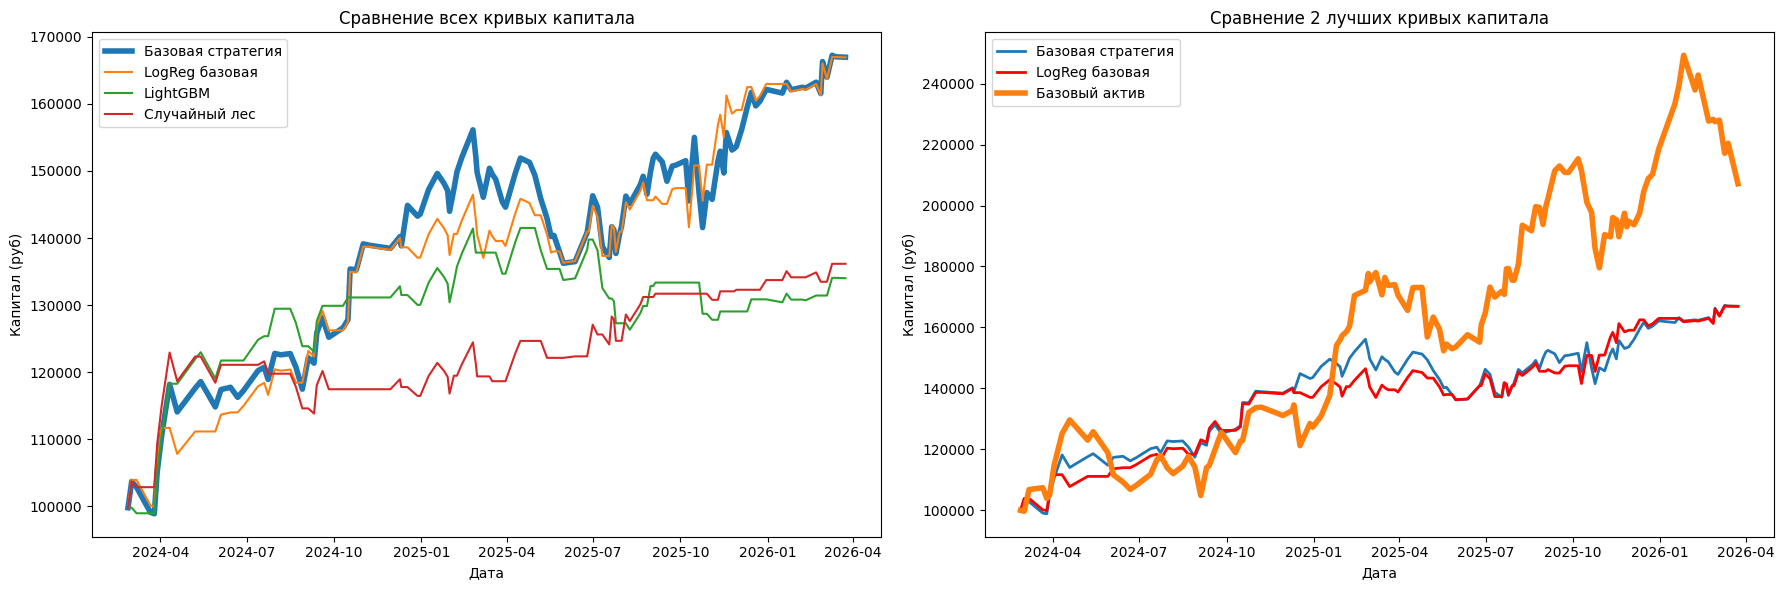

In [190]:
# Обучаем все модели
y_pred_logreg_basic = logreg_basic(X, y, max_features=10)
y_pred_logreg_poly = logreg_poly(X, y, degree=2, max_features=10)
y_pred_lightgbm = lightgbm_small(X, y, max_features=10)
y_pred_tree = decision_tree_small(X, y, max_features=10)
y_pred_rf = random_forest_small(X, y, max_features=10)

# Собираем в словарь
# models_pred = {
#     'LogReg базовая': y_pred_logreg_basic,
#     'LogReg полиномы': y_pred_logreg_poly,
#     'LightGBM': y_pred_lightgbm,
#     'Дерево решений': y_pred_tree,
#     'Случайный лес': y_pred_rf
# }
models_pred = {
    'LogReg базовая': y_pred_logreg_basic,
    'LightGBM': y_pred_lightgbm,
    'Случайный лес': y_pred_rf
}
# Визуализация
best1, best2, base = final_result_general(
    data=df_ml,
    models_predictions=models_pred,
    y_test_graph=y_test,
    share=tatneft_graph
)